In [1]:
import os, sys, pathlib, importlib
import pandas as pd
import json
import time
from tqdm import tqdm

sys.path.append(os.path.abspath(".."))
from utils import preprocess_images
from utils.preprocess_images import download_images_batch

## test

d:\miniconda3\envs\airbnb_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


10


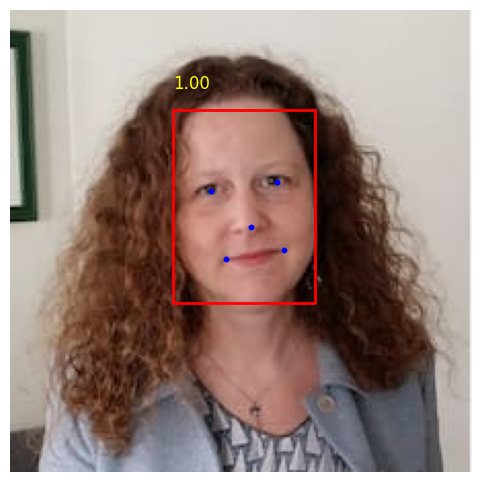

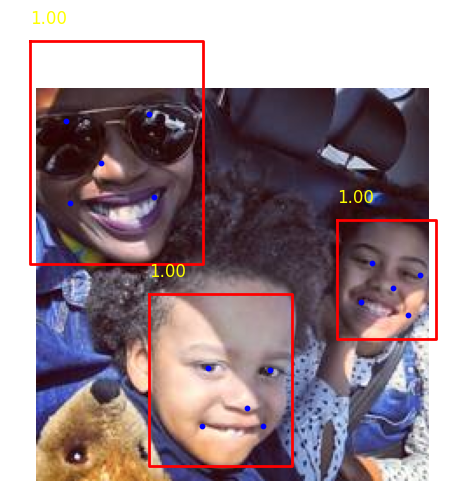

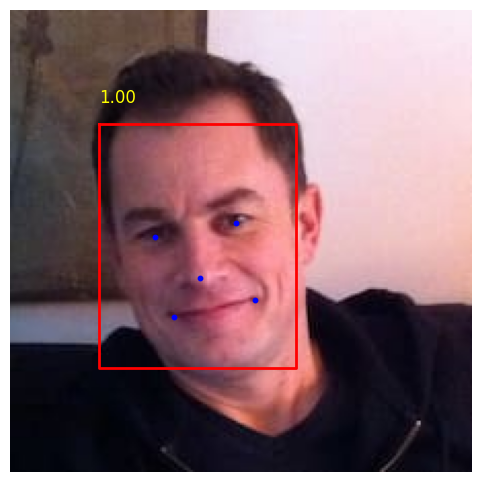

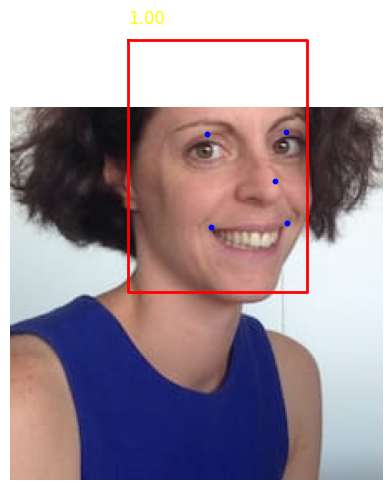

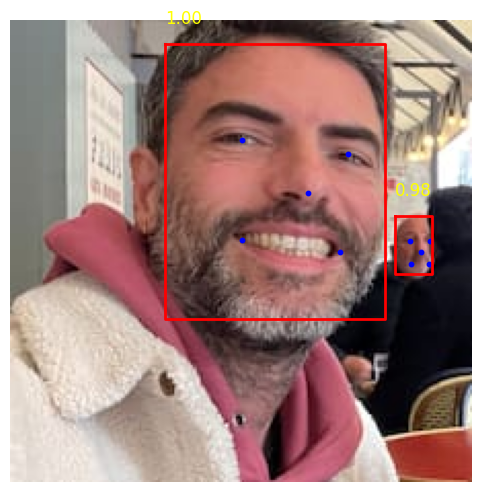

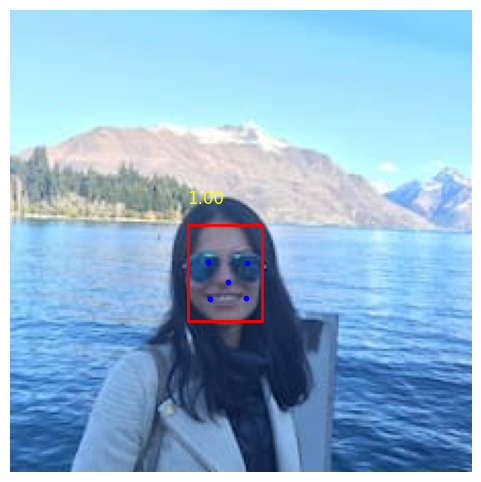

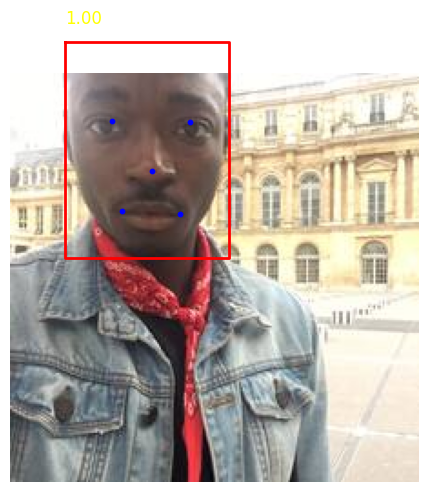

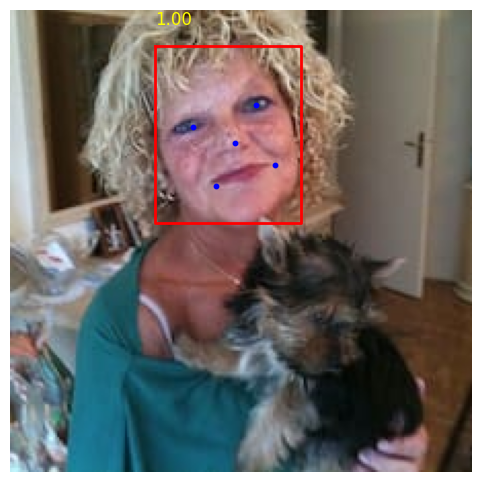

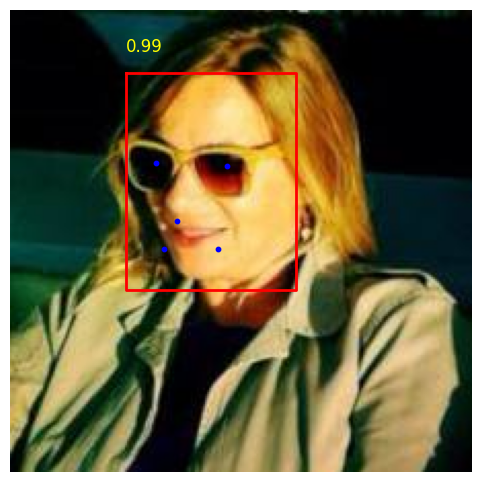

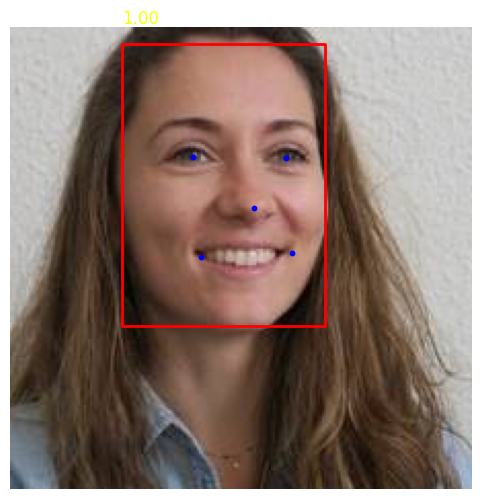

In [ ]:
import cv2 # pip install opencv-python
import matplotlib.pyplot as plt
from facenet_pytorch import MTCNN
import torch
import os

# 初始化 MTCNN
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mtcnn = MTCNN(keep_all=True, device=device)

# 测试图片路径列表
image_folder = "images\host_pic_paris2312_23933"  # 你的小批量图片目录
n_sample=10
image_files = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith((".jpg", ".png"))][:n_sample]
print(len(image_files))


for img_path in image_files:
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # MTCNN 检测
    boxes, probs, landmarks = mtcnn.detect(img_rgb, landmarks=True)

    # 可视化
    plt.figure(figsize=(6,6))
    plt.imshow(img_rgb)
    
    if boxes is not None:
        for box, prob, landmark in zip(boxes, probs, landmarks):
            x1, y1, x2, y2 = box.astype(int)
            plt.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], color='red', linewidth=2)
            plt.scatter(landmark[:,0], landmark[:,1], c='blue', s=10)  # 关键点
            plt.text(x1, y1-10, f'{prob:.2f}', color='yellow', fontsize=12)
    else:
        plt.text(10, 20, "No Face Detected", color='red', fontsize=14)

    plt.axis('off')
    plt.show()

In [ ]:
## load clip
# pip install git+https://github.com/openai/CLIP.git

# import torch
# import clip
# from PIL import Image
# import numpy as np

# device = "cuda" if torch.cuda.is_available() else "cpu"
# model, preprocess = clip.load("ViT-B/32", device=device)
# model.eval()

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [3]:
# import numpy as np
# import cv2
# from PIL import Image
# import torch
# from transformers import CLIPModel, CLIPProcessor
# # Successfully installed torch-2.10.0 torchaudio-2.10.0 torchvision-0.25.0
# device = "cuda" if torch.cuda.is_available() else "cpu"

# model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
# processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# model = model.to(device)
# model.eval()


# life_prompts = [
#     "a travel photo",
#     "a person outdoors",
#     "a restaurant scene",
#     "a sports activity",
#     "a home environment"
# ]

# nonlife_prompts = [
#     "a studio portrait",
#     "a plain wall background",
#     "a simple indoor background",
#     "a neutral background"
# ]

# all_prompts = life_prompts + nonlife_prompts


# def detect_background_clip(img, bbox_list):

#     """
#     img: numpy array (BGR from cv2)
#     bbox_list: [(x1,y1,x2,y2), ...]
#     """

#     img_copy = img.copy()
#     h, w = img_copy.shape[:2]

#     # 1️⃣ mask 掉人物区域
#     for bbox in bbox_list:
#         x1, y1, x2, y2 = bbox

#         x1 = max(0, x1)
#         y1 = max(0, y1)
#         x2 = min(w, x2)
#         y2 = min(h, y2)

#         img_copy[y1:y2, x1:x2] = (127, 127, 127)

#     # 2️⃣ 转 RGB + PIL
#     img_rgb = cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB)
#     pil_img = Image.fromarray(img_rgb)

#     # 3️⃣ 编码
#     inputs = processor(
#         text=all_prompts,
#         images=pil_img,
#         return_tensors="pt",
#         padding=True
#     ).to(device)

#     with torch.no_grad():
#         outputs = model(**inputs)

#         logits_per_image = outputs.logits_per_image
#         probs = logits_per_image.softmax(dim=1).cpu().numpy()[0]

#     life_score = float(probs[:len(life_prompts)].mean())
#     nonlife_score = float(probs[len(life_prompts):].mean())

#     is_life_background = int(life_score > nonlife_score)

#     return {
#         "life_score": life_score,
#         "nonlife_score": nonlife_score,
#         "is_life_background": is_life_background
#     }


## classification : host_pic_type

In [2]:
import torch
import numpy as np
from transformers import CLIPModel, CLIPProcessor
from PIL import Image

# 初始化一次即可（不要在循环里初始化）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")


def analyze_background_semantic(img_rgb, bbox_list):
    """
    通过life/pro标签，用clip检测背景类型。
    
    不考虑人脸，仅考虑背景，
    计算和life/pro组标签相似度的平均值哪个更高。
    """
        
    h, w, _ = img_rgb.shape
    mask = np.ones((h, w), dtype=np.uint8)

    # -- faces zone ---
    for (x1, y1, x2, y2) in bbox_list:
        mask[y1:y2, x1:x2] = 0

    # ---black face zones---
    bg_img = img_rgb.copy()
    bg_img[mask == 0] = 0

    
    # ---prompt---
    clean_prompts = [
        "a close-up headshot with a neutral wall background",
        "a portrait photo focused on a person with no other objects",
        "a professional studio profile picture"
    ]
    lifestyle_prompts = [
        "a person traveling outdoors",
        "a person on vacation in a city or nature scene",
        "a person doing sports or leisure activities",
        "a family or social gathering indoors or outdoors"
    ]
    prompts = clean_prompts + lifestyle_prompts

    
    # ---classify type of bg---
    bg_pil = Image.fromarray(bg_img)
    inputs = clip_processor(
        text=prompts,
        images=bg_pil,
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = clip_model(**inputs)
        logits = outputs.logits_per_image
        probs = logits.softmax(dim=1).cpu().numpy()[0]

    clean_score = probs[:len(clean_prompts)].mean()
    lifestyle_score = probs[len(clean_prompts):].mean()

    is_lifestyle = lifestyle_score > clean_score

    return {
        "clean_score": float(clean_score),
        "lifestyle_score": float(lifestyle_score),
        "is_lifestyle_background": bool(is_lifestyle)
    }


d:\miniconda3\envs\airbnb_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [ ]:
import numpy as np 
import cv2 
import os
import time
import json
from PIL import Image 
import torch 
from transformers import CLIPModel, CLIPProcessor 
from facenet_pytorch import MTCNN
from tqdm import tqdm



#---io---
IMAGES_FOLDER='images'
RESULTS_FOLDER="results"
image_folder = os.path.join(IMAGES_FOLDER, "host_pic_london_25051")
path_result=os.path.join(RESULTS_FOLDER,f"face_results_london.json")

save_interval=1000


# ---MTCNN检测人脸---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mtcnn = MTCNN(keep_all=True, device=device)


# ---images--- 
host_ids_all = [f.split('.')[0] for f in os.listdir(image_folder) if f.endswith((".jpg", ".png"))]#[:100]

# ---NO repetition---
with open(path_result, 'r', encoding='utf-8' ) as f:
    results=json.load(f)
    print(f"[info] {len(results)} pic classified!")
host_ids_classified=[str(res['host_id']) for res in results]
host_ids_to_clf = list(set(host_ids_all) - set(host_ids_classified)) #lists不能之间相减

image_files=[os.path.join(image_folder, f) for f in host_ids_to_clf]
print(f"[info] {len(image_files)} to classify!\n")



[info] 24819 pic classified!
[info] 0 to classify!



In [ ]:
#===========================CLF================================
start_time=time.time()
results=[]
for i, img_path in enumerate(tqdm(image_files, desc="processing images...")):
    # ----------save interval-------------
    if (i+1) % save_interval==0:
        with open(path_result, 'w', encoding="utf-8")as f:
            json.dump(results, f, indent=2, ensure_ascii=False)
            print(f"[interval save] {i+1} / {len(image_files)} results saved!\n")
             
    img_name = os.path.basename(img_path) 
    host_id = os.path.splitext(img_name)[0]
    host_id=str(host_id)
    # host_id=int(host_id)#???

    img=cv2.imread(img_path)
    
    if img is None:
        results.append({ 
            "img_path": img_path, 
            "host_id": host_id, 
            "has_face": 0, 
            "nb_face": 0, 
            "face_area_ratio": 0, 
            "avg_face_prob": 0,
            "bbox_list": [], 
            "clean_score":0,
            "lifestyle_score":0,
            "host_picture_type": "no_person"           
            }) 
        continue

    img_rgb=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _=img_rgb.shape
    img_area=h * w
    
    # ---- Face detection ---- 
    boxes, probs = mtcnn.detect(img_rgb, landmarks=False) 
    
    # 初始化：若[没有]检测到人脸:
    has_face, nb_face, face_area_ratio, avg_face_prob = 0, 0, 0, 0
    bbox_list=[]
    clean_score, lifestyle_score, host_picture_type=0, 0, "no_person" 
    
    # 若检测到人脸:
    if boxes is not None and len(boxes) > 0: # nb_face!=0
        has_face = 1 
        nb_face = len(boxes) 
        total_face_area = 0 
        valid_probs = [] 
        
        for box, prob in zip(boxes, probs): 
            if prob is None: 
                continue
            x1, y1, x2, y2 = box.astype(int) # 防止越界 
            x1 = max(0, x1) 
            y1 = max(0, y1) 
            x2 = min(w, x2) 
            y2 = min(h, y2)
            area = (x2 - x1) * (y2 - y1) 
            total_face_area += area
            
            bbox_list.append([int(x1), int(y1), int(x2), int(y2)]) 
            valid_probs.append(prob) 
            face_area_ratio = total_face_area / img_area 
            avg_face_prob = sum(valid_probs) / len(valid_probs) if valid_probs else 0
        
        if nb_face>1:
            host_picture_type='life_style'
        
        else :# nb_face==1
            bg_semantic = analyze_background_semantic(img_rgb, bbox_list)
            clean_score=bg_semantic['clean_score']
            lifestyle_score=bg_semantic['lifestyle_score']
            host_picture_type="pro_style" if clean_score > lifestyle_score else "life_style"
             

    # collect results
    results.append({
        "img_path": img_path,
        "host_id": host_id,
        "has_face": has_face,
        "nb_face": nb_face,
        "face_area_ratio": face_area_ratio,
        "avg_face_prob": avg_face_prob,
        "bbox_list": bbox_list,
        "clean_score":clean_score,
        "lifestyle_score": lifestyle_score,
        "host_picture_type":host_picture_type        
    })

end_time = time.time()

# ---save---
with open(path_result, 'w', encoding="utf-8")as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
    
print(f"[DONE] {len(results)} images detected : {end_time-start_time:.2f} sec")
print(f"[SAVE] results JSON saved to {path_result}")


processing images...: 0it [00:00, ?it/s]

[DONE] 0 images detected : 0.01 sec
[SAVE] results JSON saved to results\face_results_london.json


## VIS

In [16]:
import random
import cv2
import json
import matplotlib.pyplot as plt

path_result=os.path.join("results/face_results_london.json")
print(path_result)

with open(path_result, 'r', encoding='utf-8')as f:
    results=json.load(f)
    

def visualize_face_results(results, n_samples=10, seed=42):
    """
    随机可视化若干检测结果
    """
    random.seed(seed)
    samples = random.sample(results, min(n_samples, len(results)))
    
    n_cols = 5
    n_rows = (len(samples) + n_cols - 1) // n_cols
    
    plt.figure(figsize=(4*n_cols, 4*n_rows))
    
    for i, item in enumerate(samples):
        img = cv2.imread(item["img_path"])
        if img is None:
            continue
            
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # 画 bbox
        for bbox in item["bbox_list"]:
            x1, y1, x2, y2 = bbox
            cv2.rectangle(img_rgb, (x1,y1), (x2,y2), (255,0,0), 2)
        
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(img_rgb)
        plt.axis("off")
        

        title = (
            f"{item['host_id']}\n"
            f"has_face={item['has_face']} | nb={item['nb_face']}\n"
            # f"area_ratio={round(item['face_area_ratio'],3)}\n"
            # f"avg_prob={round(item['avg_face_prob'],3)}\n"
            f"clean_score={item['clean_score']:.2f} | lifestyle_scores={item['lifestyle_score']:.2f}\n"
            f"Type={item['host_picture_type']}"

        )
        plt.title(title, fontsize=9)
    
    plt.tight_layout()
    plt.show()

visualize_face_results(results, n_samples=50, seed=10)


results/face_results_london.json


<Figure size 2000x0 with 0 Axes>